In [ ]:
import requests 
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.optim import Adam
import glob
import time
import ccxt
import joblib                  
import os 
from datetime import datetime 
from sklearn.preprocessing import MinMaxScaler 
from sklearn.metrics import mean_squared_error, mean_absolute_error 
import matplotlib.pyplot as plt 
import tensorflow as tf 
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Flatten, Bidirectional
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

SYMBOL = "ETHUSDT"        
INTERVAL = "1m"          
LIMIT = 5000            
LOOKBACK = 100  
FUTURE = 60
TEST_RATIO = 0.15
VAL_RATIO = 0.2
EPOCHS = 30
MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

In [2]:


def create_sequences_logreturn(scaled_data, close_raw, lookback=LOOKBACK, future_steps=FUTURE):
    X, y_logreturn = [], []
    close = np.asarray(close_raw, dtype=np.float32).flatten()
    print(f"độ dài close_raw = {len(close_raw)}")
    print(f"độ dài scaled_data = {len(scaled_data)}")
    
    for i in range(lookback, len(scaled_data) - future_steps + 1):
        X.append(scaled_data[i-lookback:i])
        
        # Tính log-returns cho future_steps ngày
        future_returns = []
        for j in range(1, future_steps + 1):
            ret = np.log(close[i+j-1] / close[i+j-2])
            future_returns.append(ret)
        
        y_logreturn.append(future_returns)
    
    return np.array(X, dtype=np.float32), np.array(y_logreturn, dtype=np.float32)


    
def minmax(train_data, val_data, test_data):  # Đưa dữ liệu từ giá thực về 0-1
    scaler = MinMaxScaler()
    scaler.fit(train_data)

    train_scaled = scaler.transform(train_data)
    val_scaled   = scaler.transform(val_data)
    test_scaled  = scaler.transform(test_data)

    scaled_full = np.vstack([train_scaled, val_scaled, test_scaled])
    return scaled_full, scaler

def inverse_close(scaled_values, scaler):
    scaled_values = np.asarray(scaled_values)
    inv=scaler.inverse_transform(scaled_values)
    return inv

In [3]:

def fetch_klines(symbol=SYMBOL, interval=INTERVAL, limit=LIMIT):
        exchange = ccxt.binance()
        duration_in_seconds = exchange.parse_timeframe(interval)
        duration_in_ms = duration_in_seconds * 1000
        
        # Tính thời điểm bắt đầu: Hiện tại - (Số nến cần lấy * Thời gian 1 nến)
        # Cộng thêm buffer (ví dụ 100 nến) để trừ hao các khoảng thời gian sàn bảo trì hoặc mất dữ liệu
        now = exchange.milliseconds()
        since = now - (limit * duration_in_ms) - (100 * duration_in_ms)
        
        all_ohlcv = []
        
        # 2. Vòng lặp lấy dữ liệu (Pagination)
        while len(all_ohlcv) < limit:
            try:
                current_limit = LIMIT 
                ohlcv = exchange.fetch_ohlcv(symbol, interval, since=since, limit=current_limit)
                
                if not ohlcv:
                    break 
                
                all_ohlcv.extend(ohlcv)
                last_timestamp = ohlcv[-1][0]
                since = last_timestamp + 1
                
                # Nếu đã lấy đến hiện tại thì dừng
                if since > now:
                    break
                    
                # Thêm delay nhỏ để tránh bị sàn chặn (Rate Limit)
                time.sleep(0.1) 
                
            except Exception as e:
                print(f"Lỗi khi tải dữ liệu: {e}")
                break

        #Chuyển đổi sang DataFrame
        df = pd.DataFrame(all_ohlcv, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'])
        
        # Xử lý dữ liệu
        df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
        for col in ['open', 'high', 'low', 'close', 'volume']:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            
        df = df.dropna(subset=['open', 'high', 'low', 'close', 'volume'])
        
        df = df.drop_duplicates(subset=['timestamp'])
        if len(df) > limit:
            df = df.iloc[-limit:].reset_index(drop=True)
            
        df = df[['timestamp', 'open', 'high', 'low', 'close', 'volume']].copy()
        
        print(f"Đã tải {len(df)} nến cho {symbol}")
        return df
  
       # ---------- 1.2) Tạo các chỉ số kỹ thuật ----------
def add_features(data):
        # 1. Chuyển đổi dữ liệu
        if isinstance(data, list):
            df = pd.DataFrame(data)
        else:
            df = data.copy()
        # Đảm bảo tên cột chuẩn (nếu dữ liệu gốc viết hoa)
        df.columns = [col.lower() for col in df.columns] 
    
        # --- NHÓM 1: MOMENTUM (Xung lượng - Giữ nguyên cái tốt) ---
        df["return_1"] = df["close"].pct_change(1)   # Biến động 1 phiên
        df["return_3"] = df["close"].pct_change(3)   # Biến động 3 phiên
        df["roc_10"] = df["close"].pct_change(10)    # Rate of Change
        
        # --- NHÓM 2: VOLATILITY (Bắt buộc để bắt "độ giật") ---
        # a. Bollinger Bands Width (Báo hiệu sắp nổ Volatility)
        rolling_mean_20 = df["close"].rolling(window=20).mean()
        rolling_std_20 = df["close"].rolling(window=20).std()
        upper_band = rolling_mean_20 + (2 * rolling_std_20)
        lower_band = rolling_mean_20 - (2 * rolling_std_20)
        
        # Feature 1: Độ rộng dải băng (Co thắt = Sắp biến động mạnh)
        df["bb_width"] = (upper_band - lower_band) / rolling_mean_20
        
        # b. ATR (Average True Range) - Đo biên độ nến thực tế
        high_low = df["high"] - df["low"]
        high_close = (df["high"] - df["close"].shift()).abs()
        low_close = (df["low"] - df["close"].shift()).abs()
        
        # Lấy max của 3 giá trị trên cho từng dòng
        ranges = pd.concat([high_low, high_close, low_close], axis=1)
        true_range = ranges.max(axis=1)
        
        # Feature 2: ATR chuẩn hóa theo giá (để không bị phụ thuộc vào mức giá 60k hay 20k)
        df["atr_14_pct"] = true_range.rolling(window=14).mean() / df["close"]
    
        # --- NHÓM 3: TREND DISTANCE (Thay thế MA thô) ---
        # Thay vì đưa giá ma_5 (vd: 50000), ta đưa khoảng cách % từ giá đến MA
        # Giúp model hiểu giá đang "quá căng" (Overextended) hay đang "hồi về" (Mean Reversion)
        df["dist_ma_20"] = (df["close"] - rolling_mean_20) / rolling_mean_20
        df["dist_ma_50"] = (df["close"] - df["close"].rolling(window=50).mean()) / df["close"].rolling(window=50).mean()
    
        # --- NHÓM 4: VOLUME FLOW (Xăng cho xe chạy) ---
        # Feature 3: RVOL (Relative Volume) - Volume hiện tại gấp mấy lần trung bình?
        # Nếu dữ liệu không có volume, hãy comment dòng này lại
        if 'volume' in df.columns:
            vol_ma_20 = df["volume"].rolling(window=20).mean()
            # Cộng 1e-6 để tránh chia cho 0
            df["rvol"] = df["volume"] / (vol_ma_20 + 1e-6)
        else:
            df["rvol"] = 0 # Giá trị mặc định nếu không có volume
    
        # --- NHÓM 5: INDICATORS KHÁC ---
        df["rsi_14"] = compute_rsi(df["close"], 14) / 100.0 # Chuẩn hóa về 0-1 ngay lập tức
    
        # MACD: Lấy Histogram (quan trọng hơn đường tín hiệu để bắt đảo chiều sớm)
        ema_12 = df["close"].ewm(span=12, adjust=False).mean()
        ema_26 = df["close"].ewm(span=26, adjust=False).mean()
        macd = ema_12 - ema_26
        signal = macd.ewm(span=9, adjust=False).mean()
        
        # Feature 4: MACD Histogram
        df["macd_hist"] = macd - signal

        #======================================================================================================
        # 1. Tính toán Bollinger Bands cơ bản
        rolling_mean = df["close"].rolling(window=20).mean()
        rolling_std = df["close"].rolling(window=20).std()
        upper_band = rolling_mean + (2 * rolling_std)
        lower_band = rolling_mean - (2 * rolling_std)
        
        # --- CÁC FEATURES MỚI TỪ UPPER BAND ---
        
        # Feature 1: Khoảng cách % đến dải trên (Quan trọng nhất)
        # Dương = Đang Pump, Âm = Dưới kháng cự
        df["dist_to_upper"] = (df["close"] - upper_band) / upper_band
    
        
        # Feature 3: Breakout với Volume (Interaction Feature)
        # Ý tưởng: Giá vượt dải trên VÀ Volume lớn => Cú giật cực mạnh sắp tới
        # rvol là Relative Volume bạn đã tính trước đó
        # Đây là feature "nhân tạo" giúp model học nhanh hơn
        is_breakout = (df["close"] > upper_band).astype(float)
        df["pump_signal"] = is_breakout * df["rvol"]
        #==============================================================================================
        df = df.dropna() 
        
        # Thay thế inf nếu có (do chia cho 0)
        df = df.replace([np.inf, -np.inf], 0)
    
        # Chọn lọc Feature cuối cùng để đưa vào Model (Quan trọng!)
        # Loại bỏ 'open', 'high', 'low', 'close', 'volume' gốc và các biến trung gian
        # Chỉ giữ lại các Features đã tính toán (Stationary Features)

        
        return df


def compute_rsi(series, period=14):
        delta = series.diff()
        up = delta.clip(lower=0)
        down = -1 * delta.clip(upper=0)
        ma_up = up.ewm(com=period-1, adjust=True).mean()
        ma_down = down.ewm(com=period-1, adjust=True).mean()
        rs = ma_up / (ma_down + 1e-10)
        rsi = 100 - (100 / (1 + rs))
        return rsi

In [4]:

def load_data():
    df = fetch_klines(SYMBOL, INTERVAL, LIMIT)
    close_prices_raw = df['close'].values.astype(np.float32)
    
    n_total = len(df)
    test_size = FUTURE
    test_size_all = int(n_total*TEST_RATIO)
    val_size = int(n_total * VAL_RATIO)
    train_size = n_total - test_size_all - val_size
    
    train_size = max(train_size, LOOKBACK + 100)
    test_size = FUTURE
    val_size = max(val_size, 50)
    
    train_raw = df[:train_size]
    val_raw = df[train_size: train_size + val_size]
    train_val_data = pd.concat([train_raw, val_raw])
    test_raw = df[train_size + val_size:train_size + val_size+FUTURE]

    #print(f" {len(test_raw)}")
    test_one = test_raw[:1] # giá thực tế của bước test đầu tiên
    test_one = test_one['close'].values.astype(np.float32)
    
    max_window = max(30, LOOKBACK)  # Max size của rolling
    train_df = add_features(train_raw)
    val_with_history = pd.concat([train_raw.iloc[-max_window:], val_raw])
    val_df = add_features(val_with_history).iloc[-val_size:]  
    

    test_with_history = pd.concat([df.iloc[train_size + val_size-LOOKBACK: train_size + val_size], test_raw])
    # tập test lúc này là tập test(30) + lookback
    
    test_df = add_features(test_with_history).iloc[:LOOKBACK+1] 

    #print(f" ssssss {test_df.shape}")
    # tập test gồm giá trị đầu của tập test và lookback
    test_df_fake = add_features(test_with_history).iloc[:LOOKBACK+1]
    
    # Lấy feats data
    feats = ["close", "volume", 'return_1','return_3','roc_10',"bb_width","atr_14_pct","dist_ma_20","dist_ma_50","rvol","rsi_14","macd_hist","dist_to_upper","pump_signal"]
    
    train_data = train_df[feats].values.astype(np.float32)
    val_data = val_df[feats].values.astype(np.float32)
    test_data = test_df[feats].values.astype(np.float32)
    # tập gồm 1 giá trị test và lookback
    test_data_fake = test_df_fake[feats].values.astype(np.float32)
    
    print(f"Train shape: {train_data.shape}, Val: {val_data.shape}, Test: {test_data.shape}")
    print(f"{test_data_fake.shape}")
    scaled_full, scaler = minmax(train_data, val_data, test_data_fake)
    X_all, y_all = create_sequences_logreturn(scaled_full, close_prices_raw, LOOKBACK)
    train_count = max(0, len(train_data) - LOOKBACK)
    val_count = max(0, len(val_data))
    
    X_train = X_all[:train_count]
    y_train = y_all[:train_count]
    X_val = X_all[train_count: train_count + val_count]
    y_val = y_all[train_count: train_count + val_count]
    X_test = X_all[train_count + val_count:]
    y_test = y_all[train_count + val_count:]
    
    return X_train, y_train, X_val, y_val, X_test, y_test, scaler, close_prices_raw,test_data,test_one,test_with_history,train_val_data

In [5]:

class CNN_LSTM_MultiHeadAttention(nn.Module):
    def __init__(self, input_features=14, hidden_dim=256, 
                 num_layers=3, output_steps=FUTURE, dropout_rate=0.2, num_heads=4):
        super(CNN_LSTM_MultiHeadAttention, self).__init__()
        
        self.conv1 = nn.Conv1d(input_features, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(64)
        self.pool1 = nn.MaxPool1d(2, 2)
        
        self.conv2 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(128)
        self.pool2 = nn.MaxPool1d(2, 2)
        
        self.lstm = nn.LSTM(128, hidden_dim, num_layers=num_layers, batch_first=True,
                            dropout=dropout_rate if num_layers > 1 else 0, bidirectional=True)
        lstm_output_dim = hidden_dim * 2 
        

        self.attention = nn.MultiheadAttention(embed_dim=lstm_output_dim, 
                                               num_heads=num_heads, 
                                               dropout=dropout_rate,
                                               batch_first=True) # Quan trọng: batch_first=True
        

        self.fc1 = nn.Linear(lstm_output_dim, 256)
        self.fc2 = nn.Linear(256,128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, output_steps)
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        x = x.to(torch.float32) # (B,L,F)
        
        x = x.transpose(1, 2) # (B, F, L)
        x = self.pool1(self.relu(self.bn1(self.conv1(x))))
        x = self.dropout(x)
        x = self.pool2(self.relu(self.bn2(self.conv2(x))))
        x = self.dropout(x)
        x = x.transpose(1, 2) # (B, L', 64)
        
        lstm_out, (hn, cn) = self.lstm(x)
        #lstm_out = [B,L',512]
        
        query = torch.cat((hn[-2,:,:], hn[-1,:,:]), dim=1)
        query = query.unsqueeze(1) 
        key = lstm_out
        value = lstm_out
        
        attn_output, attn_weights = self.attention(query, key, value)
        x = attn_output.squeeze(1)
        
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc3(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc4(x)
        
        return x

In [24]:

def train_model(X_train, y_train, X_val, y_val, X_test, y_test, EPOCHS,test_data, test_one,test_with_history):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training on {device}")
    
    # Convert to tensors
    X_train_t = torch.from_numpy(X_train).float().to(device)
    y_train_t = torch.from_numpy(y_train).float().to(device)  
    X_val_t = torch.from_numpy(X_val).float().to(device)
    y_val_t = torch.from_numpy(y_val).float().to(device)  
    X_test_t = torch.from_numpy(X_test).float().to(device)
    y_test_t = torch.from_numpy(y_test).float().to(device) 
    
    train_dataset = torch.utils.data.TensorDataset(X_train_t, y_train_t)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
    
    # ==================== Initialize Model ====================
    model = CNN_LSTM_MultiHeadAttention(
        input_features=14,
        hidden_dim=128,
        num_layers=2,
        output_steps=FUTURE,  
        dropout_rate=0.2
    ).to(device)
#==================================================================================================
    criterion = nn.MSELoss()
    optimizer = Adam(model.parameters(), lr=0.001)
    print("Start training CNN-LSTM...")
    max_patience = 10
    best_val_loss = float('inf')

    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_loss = 0.0
        
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * batch_x.size(0)
        
        train_loss /= len(train_loader.dataset)
        
        # --- Validation ---
        model.eval()
        with torch.no_grad():
            val_preds = model(X_val_t)
            val_loss = criterion(val_preds, y_val_t).item()
            print(f"Epoch {epoch}: Train Loss = {train_loss:.6f}, Val Loss = {val_loss:.6f}")

        # --- Early Stopping Logic ---
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), os.path.join(MODEL_DIR, "best_coin_cnn_lstm.pth"))
        else:

            patience_counter += 1

        if patience_counter >= max_patience:
            print(f"Early stopping triggered at epoch {epoch}. Training finished.")
            break

        # ======================================= Testing ===========================================

    
    print("Loading best model for walk-forward testing...")
    model.load_state_dict(torch.load(os.path.join(MODEL_DIR, "best_coin_cnn_lstm.pth")))
    model.eval()
    device = next(model.parameters()).device
    
        # Dự đoán 30 bước tiếp theo từ bước đầu tiên của test
    print(f"1")
    with torch.no_grad():
        # 1. Chuyển sang tensor và đưa vào GPU
        X_first = torch.from_numpy(test_data[:-1]).float().to(device)
        # print(f"{X_first.shape}") # torch.Size([200, 12])
        X_first = X_first.unsqueeze(0) 

        # print(f"{X_first.shape}") #  torch.Size([1,200, 12])
        # 3. Dự đoán
        pred_logr = model(X_first).cpu().numpy().reshape(-1)
        initial_price = test_one # test_one là giá close của bước test đầu tiên 
        pred_prices = initial_price * np.cumprod(np.exp(pred_logr))
        
        #print(f"{pred_prices}")
        

    actuals_future = test_with_history.iloc[-FUTURE:]['close'].values
    
    print(f"Initial price: {initial_price}")
    print(f"Predicted next {FUTURE} prices: {pred_prices}")
    print(f"Actual next {FUTURE} prices: {actuals_future}")
    return pred_prices, actuals_future

In [7]:


def plot_test_comparison2(test_actual, test_preds, title="So sánh Dự đoán và Thực tế (Chỉ tập Test)"):
    """
    Vẽ biểu đồ so sánh CHỈ giá trị thực tế và dự đoán của tập Test.
    
    Parameters:
    - test_actual: Array chứa giá thực tế của test (Ground Truth)
    - test_preds: Array chứa giá dự đoán của test (Prediction)
    """
    
    # 1. Chuẩn bị dữ liệu (Flatten để đảm bảo là mảng 1 chiều)
    # Chuyển về numpy array phòng trường hợp đầu vào là list hoặc tensor
    y_true = np.array(test_actual).flatten()
    y_pred = np.array(test_preds).flatten()
    
    # Tạo index (trục thời gian) bắt đầu từ 0 đến hết tập test
    steps = np.arange(len(y_true))
    
    # 2. Khởi tạo Biểu đồ
    plt.figure(figsize=(14, 7))
    
    # 3. Vẽ đường Thực tế (Actual)
    plt.plot(steps, y_true, label='Giá trị Thực tế (Actual)', 
             color='#007acc', linewidth=2.5, marker='o', markersize=5, alpha=0.9)
    
    # 4. Vẽ đường Dự đoán (Prediction)
    plt.plot(steps, y_pred, label='Giá trị Dự đoán (Prediction)', 
             color='#ff4d4d', linewidth=2, linestyle='--', marker='x', markersize=6, alpha=0.9)
    
    # 5. Tô màu vùng sai số (Error Gap)
    # Giúp nhìn rõ đoạn nào mô hình dự đoán sai nhiều nhất
    plt.fill_between(steps, y_true, y_pred, color='gray', alpha=0.2, label='Biên độ sai số (Error Gap)')
    
    # 6. Vẽ đường xu hướng (Trendlines) - Tùy chọn để xem mô hình có bắt được hướng đi không
    if len(y_true) > 1:
        # Xu hướng thực tế
        z_true = np.polyfit(steps, y_true, 1)
        p_true = np.poly1d(z_true)
        plt.plot(steps, p_true(steps), color='blue', linestyle=':', alpha=0.5, linewidth=1)
        
        # Xu hướng dự đoán
        z_pred = np.polyfit(steps, y_pred, 1)
        p_pred = np.poly1d(z_pred)
        plt.plot(steps, p_pred(steps), color='red', linestyle=':', alpha=0.5, linewidth=1)

    # 7. Formatting (Trang trí)
    plt.title(title, fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Các bước thời gian (Time Steps)', fontsize=12)
    plt.ylabel('Giá (Price)', fontsize=12)
    plt.legend(loc='best', fontsize=11, frameon=True, shadow=True)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Đánh dấu trục X là số nguyên
    plt.xticks(steps, rotation=45 if len(steps) > 20 else 0)
    
    plt.tight_layout()
    plt.show()
    
    # 8. In thống kê chi tiết
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"\n{'='*50}")
    print(f"📊 THỐNG KÊ KẾT QUẢ TEST")
    print(f"{'-'*50}")
    print(f"🔹 Số lượng mẫu test: {len(y_true)}")
    print(f"🔹 MAE (Sai số tuyệt đối trung bình): {mae:.4f}")
    print(f"🔹 RMSE (Căn bậc hai sai số bình phương): {rmse:.4f}")
    print(f"🔹 MAPE (Sai số phần trăm trung bình): {mape:.2f}%")
    
    # Tính độ chính xác hướng đi (Directional Accuracy)
    # So sánh dấu của (Giá[t] - Giá[t-1]) giữa thực tế và dự đoán
    if len(y_true) > 1:
        diff_true = np.diff(y_true)
        diff_pred = np.diff(y_pred)
        correct_direction = np.sum(np.sign(diff_true) == np.sign(diff_pred))
        direction_acc = (correct_direction / len(diff_true)) * 100
        print(f"🔹 Directional Accuracy (Đoán đúng xu hướng tăng/giảm): {direction_acc:.2f}%")
        
    print(f"{'='*50}\n")

Đã tải 3000 nến cho ETHUSDT
Train shape: (1901, 14), Val: (600, 14), Test: (101, 14)
(101, 14)
độ dài close_raw = 3000
độ dài scaled_data = 2602
Training on cpu
Start training CNN-LSTM...
Epoch 1: Train Loss = 0.000968, Val Loss = 0.000016
Epoch 2: Train Loss = 0.000116, Val Loss = 0.000006
Epoch 3: Train Loss = 0.000070, Val Loss = 0.000005
Epoch 4: Train Loss = 0.000048, Val Loss = 0.000003
Epoch 5: Train Loss = 0.000035, Val Loss = 0.000004
Epoch 6: Train Loss = 0.000026, Val Loss = 0.000002
Epoch 7: Train Loss = 0.000019, Val Loss = 0.000002
Epoch 8: Train Loss = 0.000015, Val Loss = 0.000002
Epoch 9: Train Loss = 0.000011, Val Loss = 0.000002
Epoch 10: Train Loss = 0.000009, Val Loss = 0.000002
Epoch 11: Train Loss = 0.000007, Val Loss = 0.000002
Epoch 12: Train Loss = 0.000005, Val Loss = 0.000002
Epoch 13: Train Loss = 0.000004, Val Loss = 0.000002
Epoch 14: Train Loss = 0.000003, Val Loss = 0.000001
Epoch 15: Train Loss = 0.000003, Val Loss = 0.000001
Epoch 16: Train Loss = 0.0

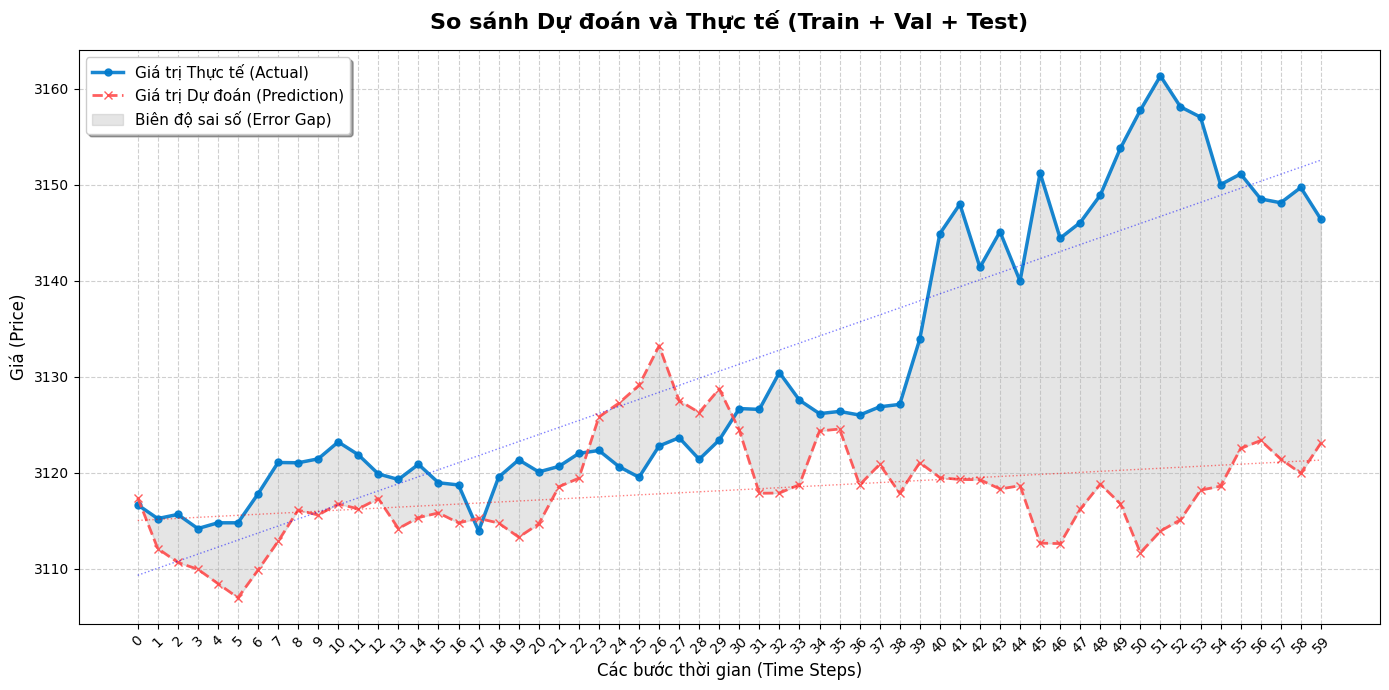


📊 THỐNG KÊ KẾT QUẢ TEST
--------------------------------------------------
🔹 Số lượng mẫu test: 60
🔹 MAE (Sai số tuyệt đối trung bình): 14.3043
🔹 RMSE (Căn bậc hai sai số bình phương): 19.4609
🔹 MAPE (Sai số phần trăm trung bình): 0.46%
🔹 Directional Accuracy (Đoán đúng xu hướng tăng/giảm): 47.46%



In [27]:
def main():
  X_train, y_train, X_val, y_val, X_test, y_test, scaler, close_prices_raw,test_data,test_one,test_with_history ,train_val_data= load_data()
  test_preds, test_actual = train_model(X_train, y_train, X_val, y_val, X_test, y_test, EPOCHS,test_data, test_one,test_with_history)
  plot_test_comparison2( test_actual, test_preds, title="So sánh Dự đoán và Thực tế (Train + Val + Test)")

if __name__ == "__main__":  
    main()